In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import pyvinecopulib as pv
from scipy import stats
from scipy.stats import rankdata
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid
from utils import load_g09_waveswide_xys, plot_marginal_fits, plot_uniform_marginals
from probability_funcs import forward_cdf, density, xy2xy_parameteric_cdf_transform, xy2xy_empirical_cdf_transform, fit_all_marginals, fit_all_marginals_empirical
from copula_funcs import train_copulas_empirical, train_copulas_parametric, get_completeness_empirical, get_completeness_parametric
from copula_completeness_estimator import CopulaCompletenessEstimator

In [23]:
xy_all, xy_fn, xy_all_tp_mask = load_g09_waveswide_xys()

/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/copula_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inp

x_all                      linear(-0.074x + 0.390)
x_fn                       w=0.469  linear(-2.526x + 2.269)  N(1.029, 1.077)
y_all                      w=0.698  N(0.734, 0.210)  N(1.358, 0.214)
y_fn                       N(1.082, 0.330)


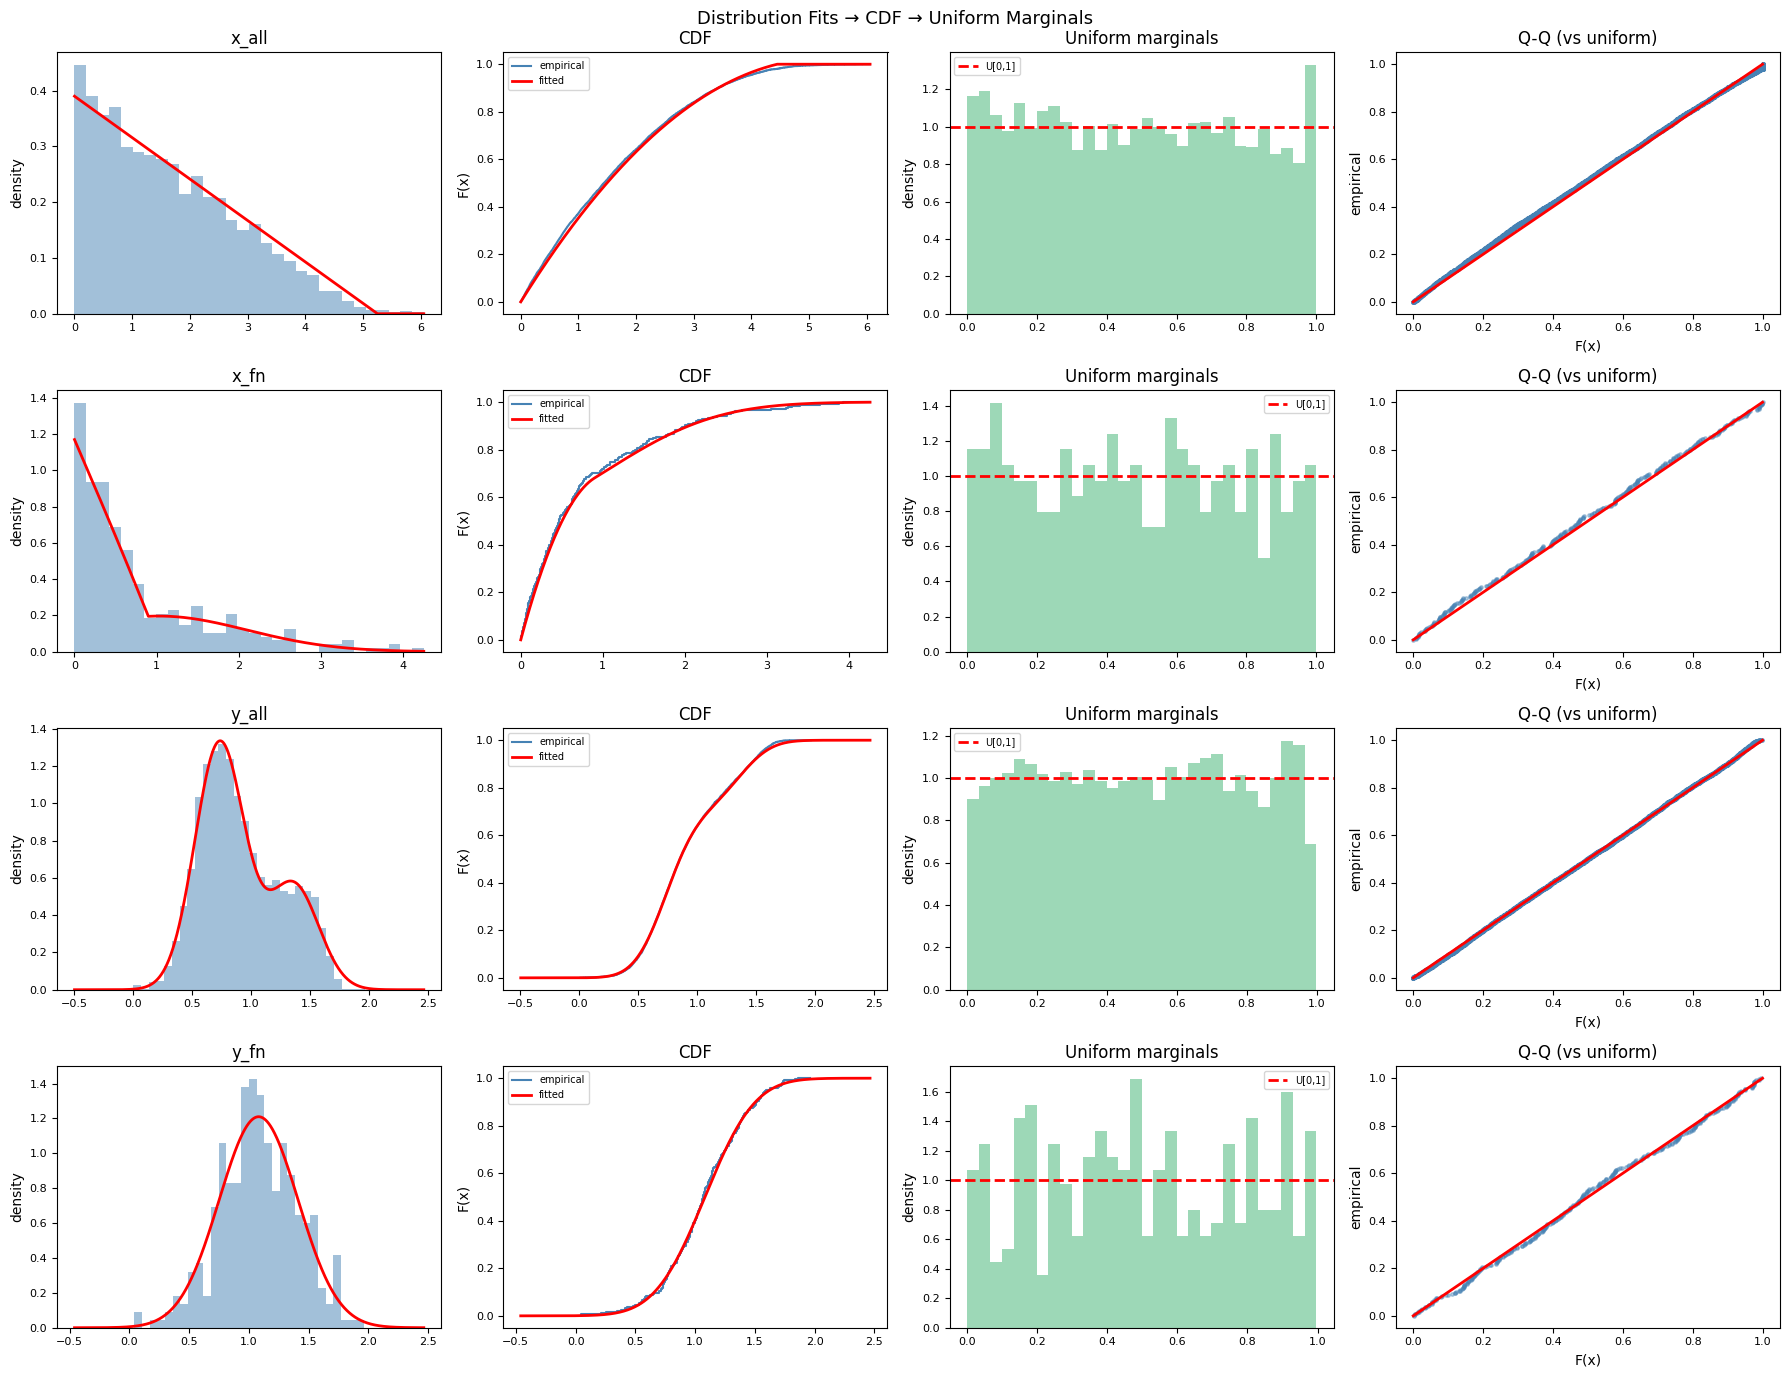

Parametric copula fits:
All: <pyvinecopulib.Bicop> Bivariate copula: 
  family = BB8
  rotation = 0
  var_types = c,c
  parameters =  3.1
0.74

FN: <pyvinecopulib.Bicop> Bivariate copula: 
  family = BB8
  rotation = 0
  var_types = c,c
  parameters =  1.8
0.97

All Fits...


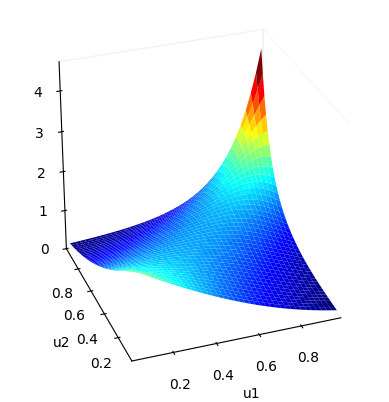

FN Fits...


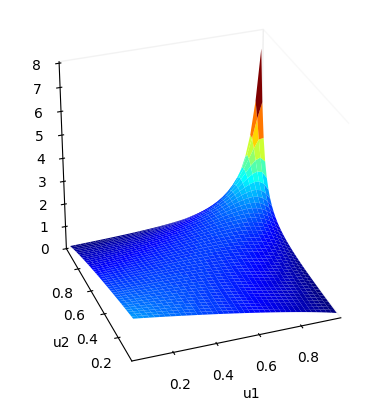

[[0.28669683 0.14612947]
 [0.5608958  0.23028277]
 [0.19285133 0.05461307]
 ...
 [0.10268782 0.39032295]
 [0.06882675 0.20174076]
 [0.14567202 0.23423823]]


In [42]:
completeness_estimator = CopulaCompletenessEstimator(type='parametric')
completeness_estimator.set_xy(xy_all)
completeness_estimator.set_xy_fn_mask(xy_all_tp_mask)
completeness_estimator.train_copula_model(make_plots=True)
para_completeness = completeness_estimator.find_completeness()
para_comp_mask = completeness_estimator.apply_completeness_as_selection()

x_all                      empirical ECDF  [0.000, 5.004]  n=6535
x_fn                       empirical ECDF  [0.000, 3.538]  n=339
y_all                      empirical ECDF  [0.004, 1.765]  n=6535
y_fn                       empirical ECDF  [0.044, 1.841]  n=339


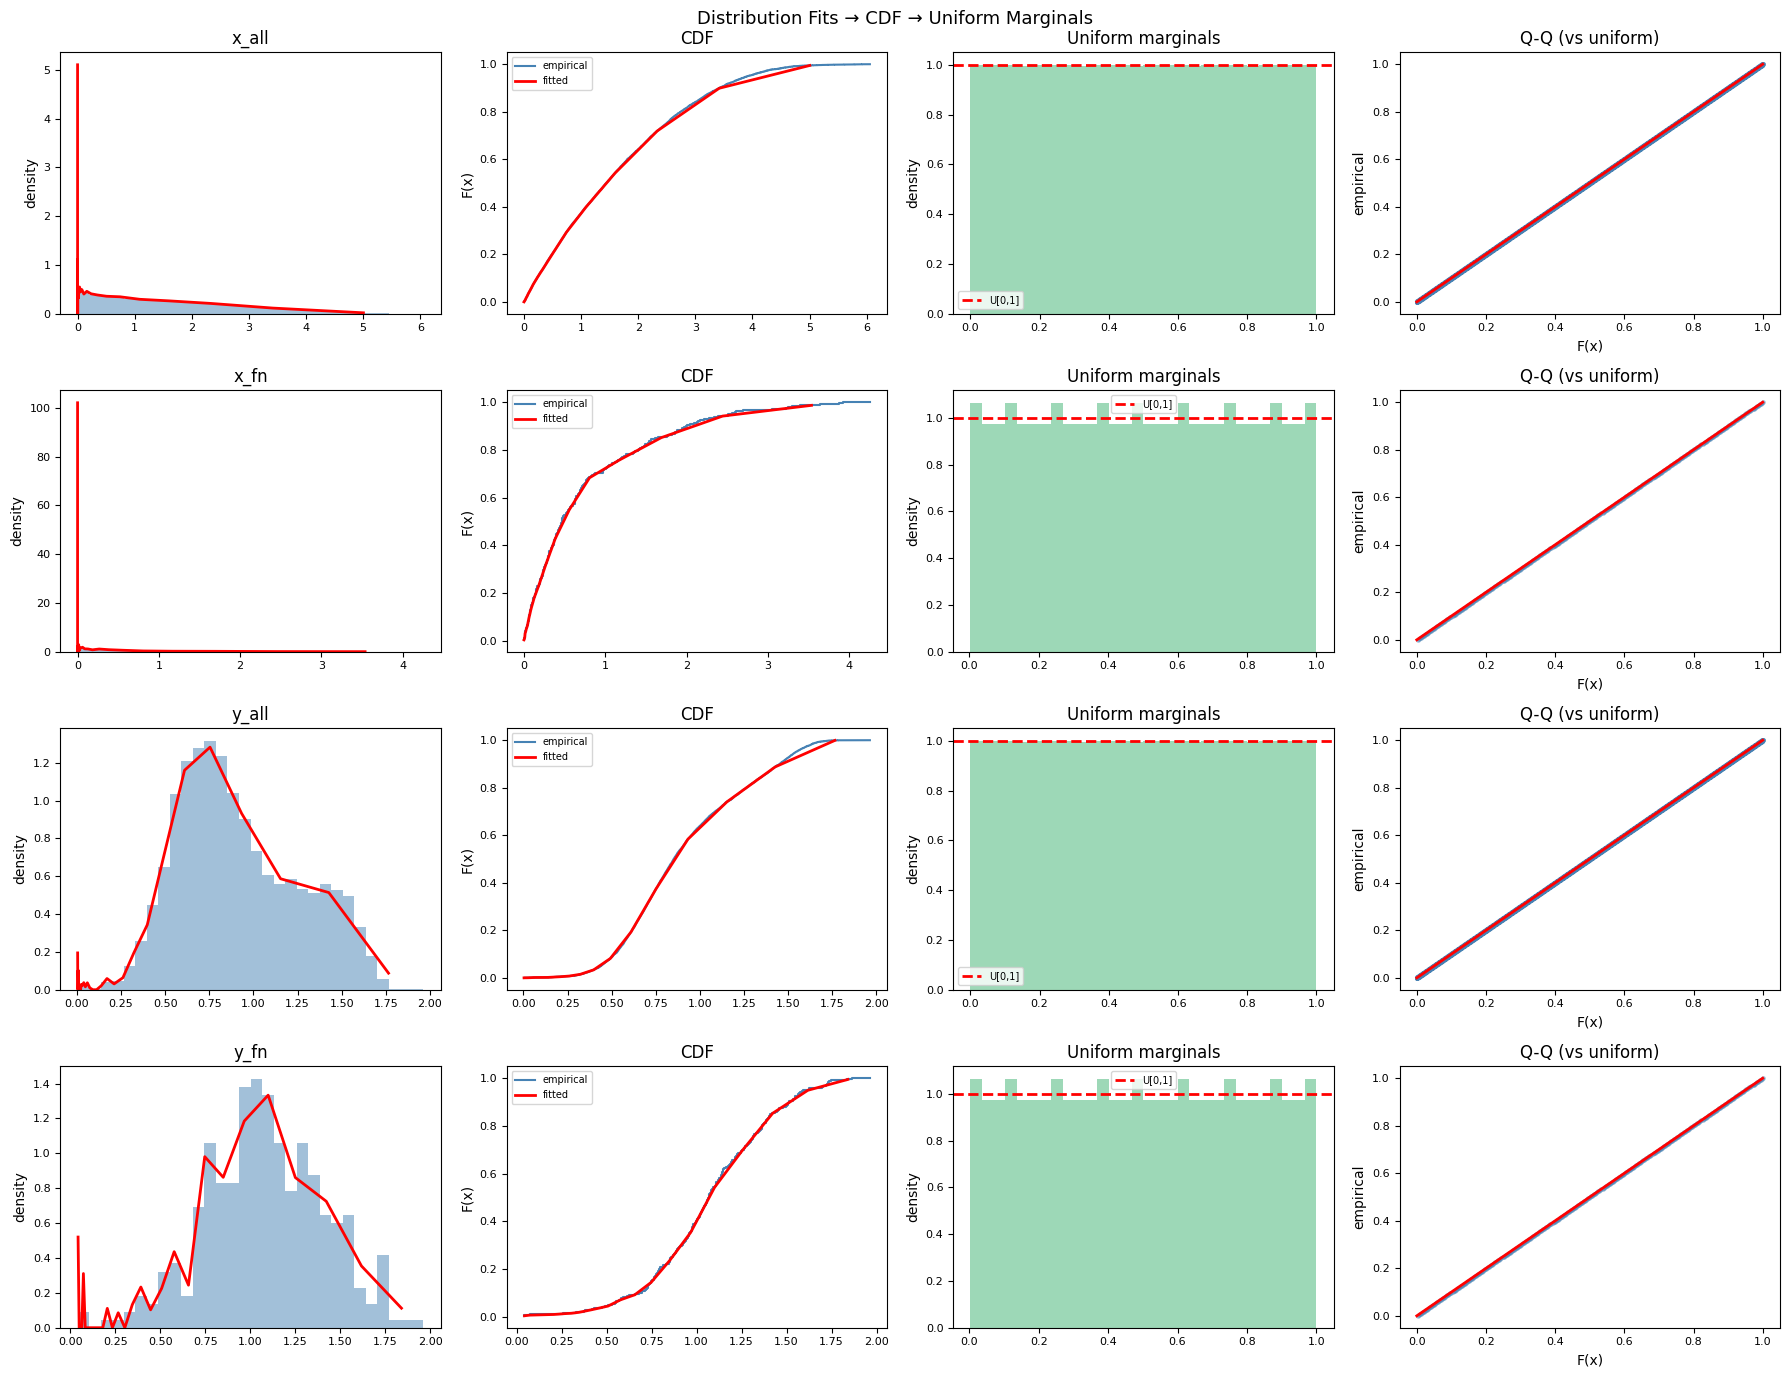

Empirical TLL copula fits:
All: <pyvinecopulib.Bicop> Bivariate copula: 
  family = TLL
  rotation = 0
  var_types = c,c
  parameters = [30x30 grid] with 1.1e+02 d.f.

FN: <pyvinecopulib.Bicop> Bivariate copula: 
  family = TLL
  rotation = 0
  var_types = c,c
  parameters = [30x30 grid] with 29 d.f.

All Fits...


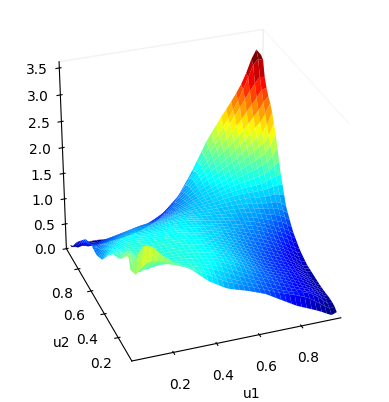

FN Fits...


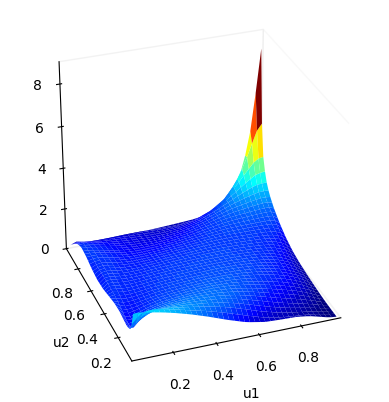

In [43]:
completeness_estimator_emp = CopulaCompletenessEstimator(type='empirical')
completeness_estimator_emp.set_xy(xy_all)
completeness_estimator_emp.set_xy_fn_mask(xy_all_tp_mask)
completeness_estimator_emp.train_copula_model(make_plots=True)
emp_completeness = completeness_estimator_emp.find_completeness()
emp_comp_mask = completeness_estimator_emp.apply_completeness_as_selection()

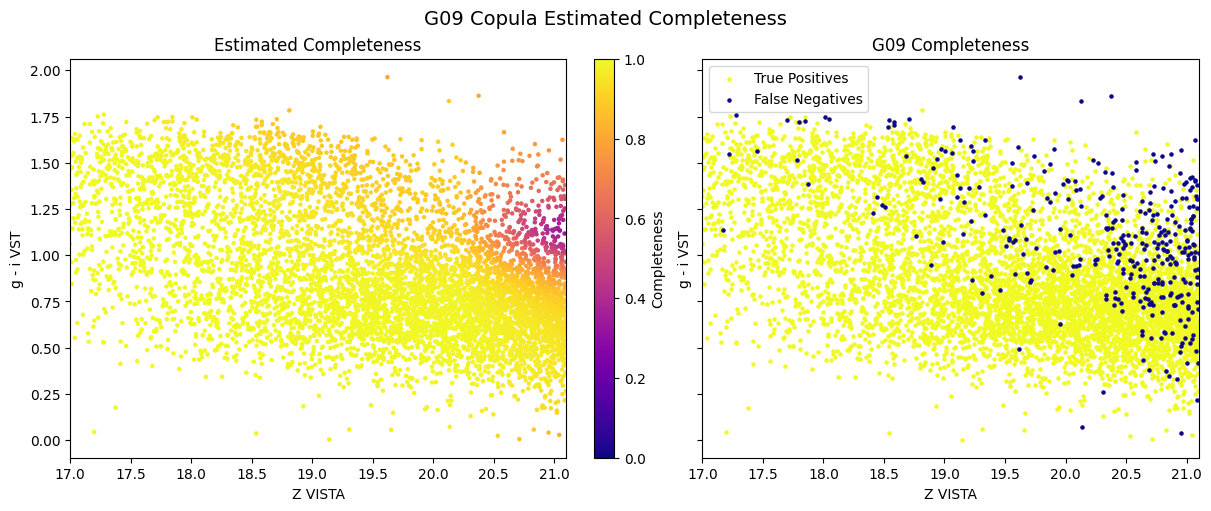

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True, constrained_layout=True)

sc0 = ax[0].scatter(-xy_all[:, 0] + 21.1, xy_all[:, 1], c=para_completeness, s=5, cmap='plasma', vmin=0, vmax=1)
fig.colorbar(sc0, ax=ax[0], label='Completeness')
ax[0].set_title('Estimated Completeness')
ax[0].set_xlabel('Z VISTA')
ax[0].set_ylabel('g - i VST')
ax[0].set_xlim(17, 21.1)

tps = xy_all[xy_all_tp_mask == 1]
fns = xy_all[xy_all_tp_mask == 0]

ax[1].scatter(-tps[:, 0] + 21.1, tps[:, 1], s=5, color='#F0F921', label='True Positives')
ax[1].scatter(-fns[:, 0] + 21.1, fns[:, 1], s=5, color='#0D0887', label='False Negatives')
ax[1].set_title('G09 Completeness')
ax[1].set_xlabel('Z VISTA')
ax[1].set_ylabel('g - i VST')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].legend()
fig.suptitle("G09 Copula Estimated Completeness", fontsize=14)
plt.savefig("completeness_map.png", dpi=150)
plt.show()

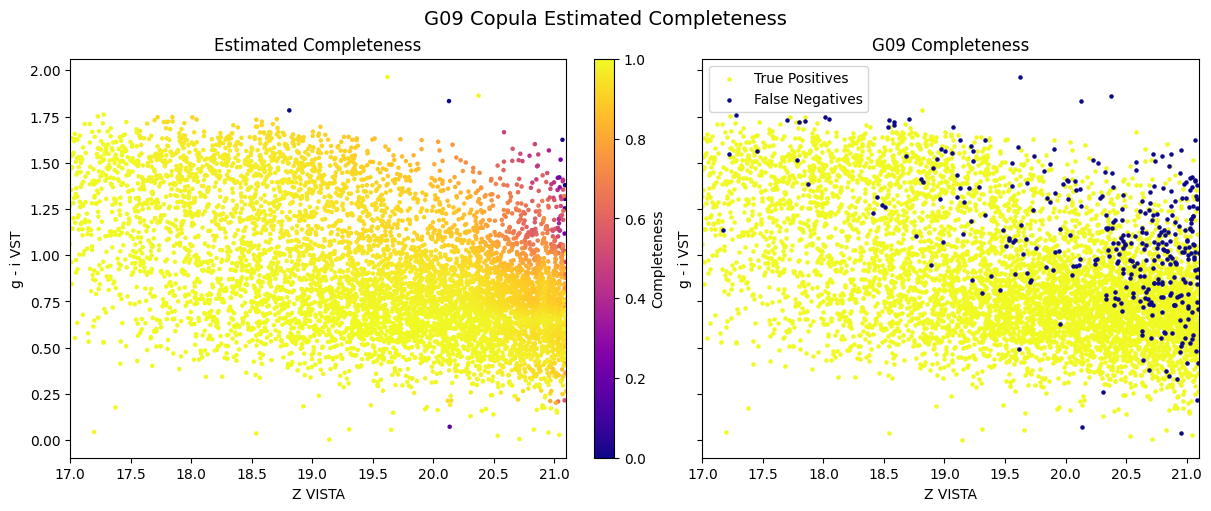

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True, constrained_layout=True)

sc0 = ax[0].scatter(-xy_all[:, 0] + 21.1, xy_all[:, 1], c=emp_completeness, s=5, cmap='plasma', vmin=0, vmax=1)
fig.colorbar(sc0, ax=ax[0], label='Completeness')
ax[0].set_title('Estimated Completeness')
ax[0].set_xlabel('Z VISTA')
ax[0].set_ylabel('g - i VST')
ax[0].set_xlim(17, 21.1)

tps = xy_all[xy_all_tp_mask == 1]
fns = xy_all[xy_all_tp_mask == 0]

ax[1].scatter(-tps[:, 0] + 21.1, tps[:, 1], s=5, color='#F0F921', label='True Positives')
ax[1].scatter(-fns[:, 0] + 21.1, fns[:, 1], s=5, color='#0D0887', label='False Negatives')
ax[1].set_title('G09 Completeness')
ax[1].set_xlabel('Z VISTA')
ax[1].set_ylabel('g - i VST')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].legend()
fig.suptitle("G09 Copula Estimated Completeness", fontsize=14)
plt.savefig("completeness_map.png", dpi=150)
plt.show()

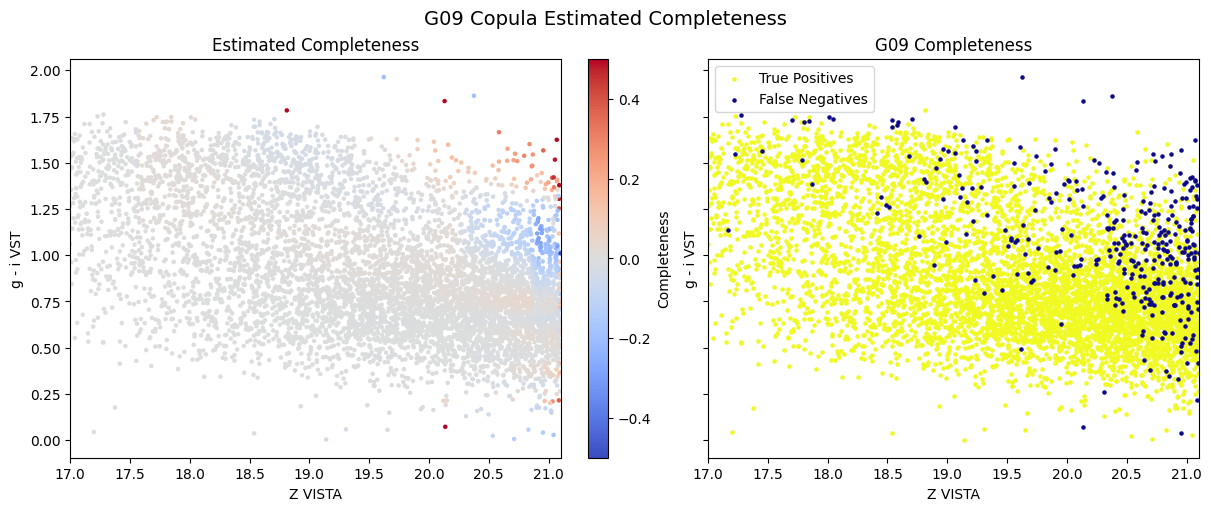

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True, constrained_layout=True)

sc0 = ax[0].scatter(-xy_all[:, 0] + 21.1, xy_all[:, 1], c=para_completeness - emp_completeness, s=5, cmap='coolwarm', vmin=-0.5, vmax=0.5)
fig.colorbar(sc0, ax=ax[0], label='Completeness')
ax[0].set_title('Estimated Completeness')
ax[0].set_xlabel('Z VISTA')
ax[0].set_ylabel('g - i VST')
ax[0].set_xlim(17, 21.1)

tps = xy_all[xy_all_tp_mask == 1]
fns = xy_all[xy_all_tp_mask == 0]

ax[1].scatter(-tps[:, 0] + 21.1, tps[:, 1], s=5, color='#F0F921', label='True Positives')
ax[1].scatter(-fns[:, 0] + 21.1, fns[:, 1], s=5, color='#0D0887', label='False Negatives')
ax[1].set_title('G09 Completeness')
ax[1].set_xlabel('Z VISTA')
ax[1].set_ylabel('g - i VST')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].legend()
fig.suptitle("G09 Copula Estimated Completeness", fontsize=14)
plt.savefig("completeness_map.png", dpi=150)
plt.show()

(17.0, 21.1)

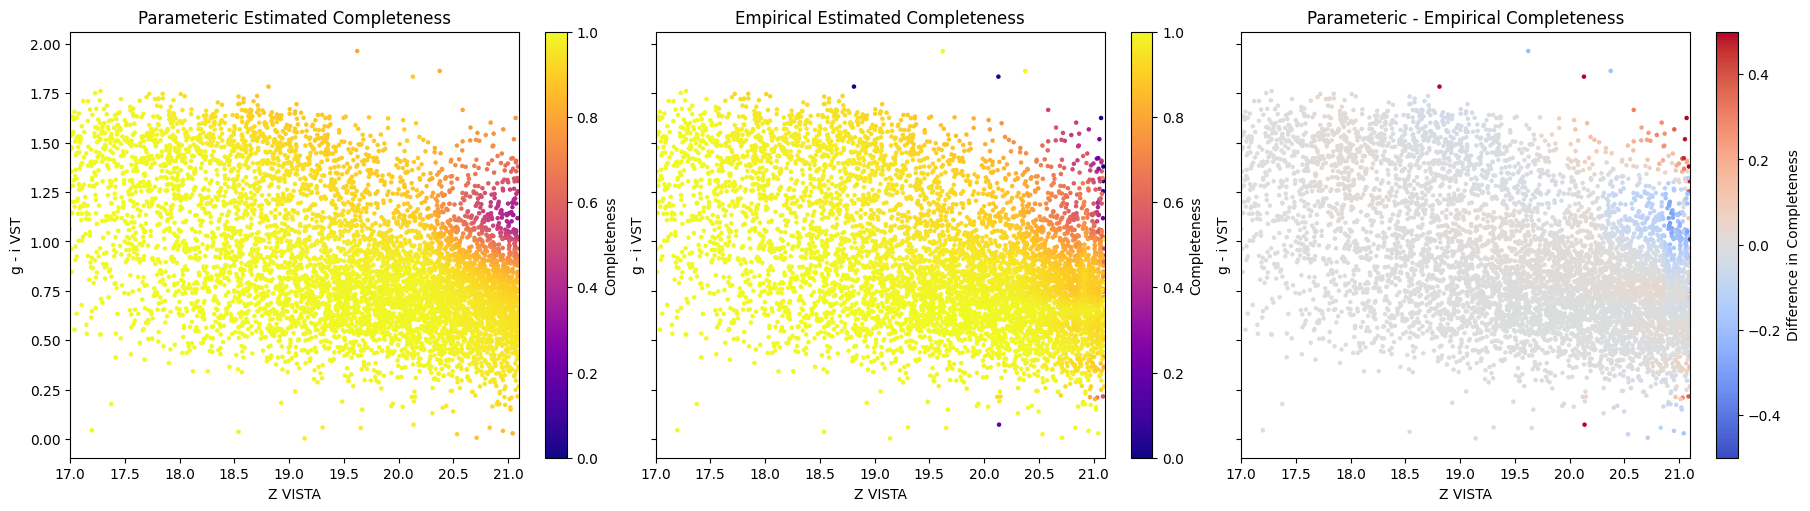

In [29]:
fig, ax = plt.subplots(1, 3 ,figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)
sc0 = ax[0].scatter(-xy_all[:, 0] + 21.1, xy_all[:, 1], c=para_completeness, s=5, cmap='plasma', vmin=0, vmax=1)
fig.colorbar(sc0, ax=ax[0], label='Completeness')
ax[0].set_title('Parameteric Estimated Completeness')
ax[0].set_xlabel('Z VISTA')
ax[0].set_ylabel('g - i VST')
ax[0].set_xlim(17, 21.1)

sc0 = ax[1].scatter(-xy_all[:, 0] + 21.1, xy_all[:, 1], c=emp_completeness, s=5, cmap='plasma', vmin=0, vmax=1)
fig.colorbar(sc0, ax=ax[1], label='Completeness')
ax[1].set_title('Empirical Estimated Completeness')
ax[1].set_xlabel('Z VISTA')
ax[1].set_ylabel('g - i VST')
ax[1].set_xlim(17, 21.1)

sc0 = ax[2].scatter(-xy_all[:, 0] + 21.1, xy_all[:, 1], c=para_completeness - emp_completeness, s=5, cmap='coolwarm', vmin=-0.5, vmax=0.5)
fig.colorbar(sc0, ax=ax[2], label='Difference in Completeness')
ax[2].set_title('Parameteric - Empirical Completeness')
ax[2].set_xlabel('Z VISTA')
ax[2].set_ylabel('g - i VST')
ax[2].set_xlim(17, 21.1)

In [30]:
print("Completeness Fiducial", np.sum(xy_all_tp_mask) / len(xy_all_tp_mask))
print("Completeness Parameteric", np.sum(para_comp_mask) / len(para_comp_mask))
print("Completeness Empirical", np.sum(emp_comp_mask) / len(emp_comp_mask))

Completeness Fiducial 0.9481254781943382
Completeness Parameteric 0.9488905891354247
Completeness Empirical 0.9524100994644223


In [19]:
def load_shark():

    sharks = pd.read_parquet('/Users/sp624AA/Downloads/group_finding_mocks/galaxies_shark.parquet')
    cols_to_keep = ['redshift_observed', 'mag_g_VST', 'mag_i_VST', 'mag_Z_VISTA', 'mass_stellar_total', 'id_fof', 'id_group_sky', 'mag_abs_Z_VISTA']

    sharks = sharks[cols_to_keep]
    sharks['g-i'] = sharks['mag_g_VST'] - sharks['mag_i_VST']
    sel_sharks = (sharks['mag_Z_VISTA'] < 21.1) * (sharks['redshift_observed'] < 0.2) * (sharks['mass_stellar_total'] > 8)
    wide_sharks = sharks[sel_sharks].reset_index(drop=True)
    xy_sharks = np.column_stack([-wide_sharks['mag_Z_VISTA'] + 21.1, wide_sharks['g-i']])

    subsample_bool = np.random.rand(len(wide_sharks)) < 0.01
    return xy_sharks, wide_sharks, subsample_bool

xy_sharks, wide_sharks, subsample_bool = load_shark()

In [21]:
completeness_estimator_emp.set_xy(xy_sharks)
sharks_completeness_emp = completeness_estimator_emp.find_completeness()

completeness_estimator.set_xy(xy_sharks)
sharks_completeness_para = completeness_estimator.find_completeness()

[[0.12625685 0.47289338]
 [0.94081753 0.76471034]
 [0.53412697 0.53069722]
 ...
 [0.21710564 0.45165322]
 [0.91676192 0.73874165]
 [0.34419811 0.09211277]]


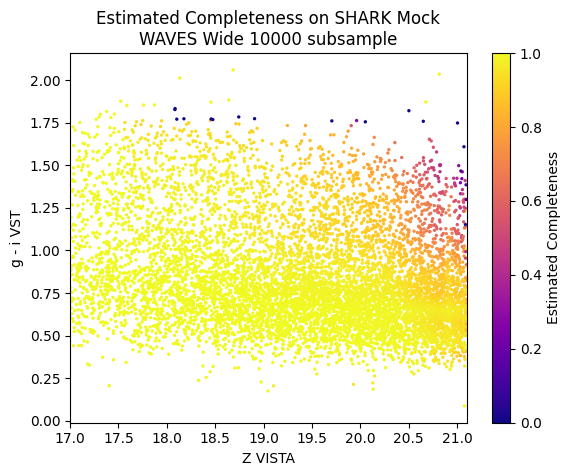

In [ ]:
plt.scatter(21.1-xy_sharks[:, 0][subsample_bool], xy_sharks[:, 1][subsample_bool], c=sharks_completeness_emp[subsample_bool], s = 2, cmap='plasma', vmin=0, vmax=1)
plt.colorbar(label='Estimated Completeness')
plt.xlabel('Z VISTA')
plt.ylabel('g - i VST')
plt.xlim(17, 21.1)
plt.title(f'Estimated Completeness on SHARK Mock\nWAVES Wide 10000 subsample')
plt.savefig("completeness_map_shark.png", dpi=150)

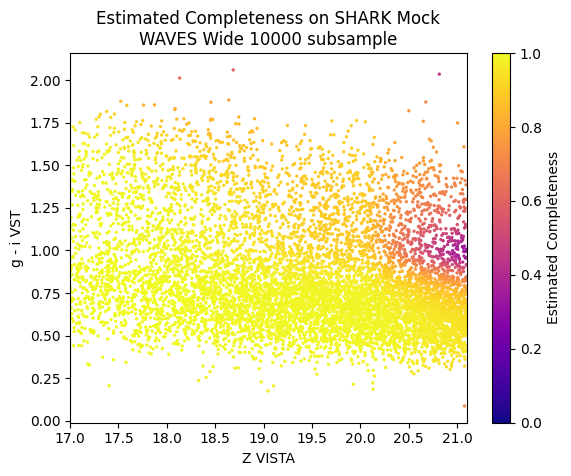

In [36]:
plt.scatter(21.1-xy_sharks[:, 0][subsample_bool], xy_sharks[:, 1][subsample_bool], c=sharks_completeness_para[subsample_bool], s = 2, cmap='plasma', vmin=0, vmax=1)
plt.colorbar(label='Estimated Completeness')
plt.xlabel('Z VISTA')
plt.ylabel('g - i VST')
plt.xlim(17, 21.1)
plt.title(f'Estimated Completeness on SHARK Mock\nWAVES Wide 10000 subsample')
plt.savefig("completeness_map_shark.png", dpi=150)  

(17.0, 21.1)

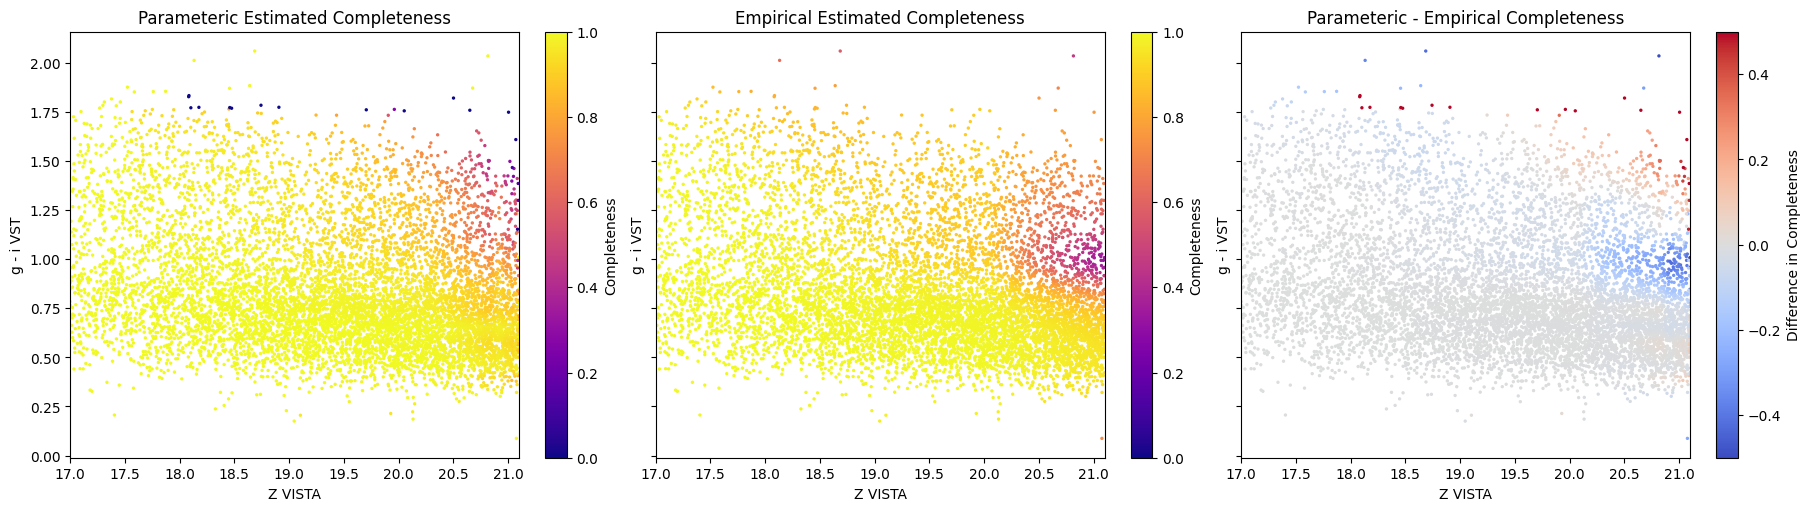

In [38]:
fig, ax = plt.subplots(1, 3 ,figsize=(18, 5), sharex=True, sharey=True, constrained_layout=True)
sc0 = ax[0].scatter(21.1-xy_sharks[:, 0][subsample_bool], xy_sharks[:, 1][subsample_bool], c=sharks_completeness_emp[subsample_bool], s = 2, cmap='plasma', vmin=0, vmax=1)
fig.colorbar(sc0, ax=ax[0], label='Completeness')
ax[0].set_title('Parameteric Estimated Completeness')
ax[0].set_xlabel('Z VISTA')
ax[0].set_ylabel('g - i VST')
ax[0].set_xlim(17, 21.1)

sc0 = ax[1].scatter(21.1-xy_sharks[:, 0][subsample_bool], xy_sharks[:, 1][subsample_bool], c=sharks_completeness_para[subsample_bool], s = 2, cmap='plasma', vmin=0, vmax=1)
fig.colorbar(sc0, ax=ax[1], label='Completeness')
ax[1].set_title('Empirical Estimated Completeness')
ax[1].set_xlabel('Z VISTA')
ax[1].set_ylabel('g - i VST')
ax[1].set_xlim(17, 21.1)

sc0 = ax[2].scatter(21.1-xy_sharks[:, 0][subsample_bool], xy_sharks[:, 1][subsample_bool], c=sharks_completeness_para[subsample_bool] - sharks_completeness_emp[subsample_bool], s = 2, cmap='coolwarm', vmin=-0.5, vmax=0.5)
fig.colorbar(sc0, ax=ax[2], label='Difference in Completeness')
ax[2].set_title('Parameteric - Empirical Completeness')
ax[2].set_xlabel('Z VISTA')
ax[2].set_ylabel('g - i VST')
ax[2].set_xlim(17, 21.1)

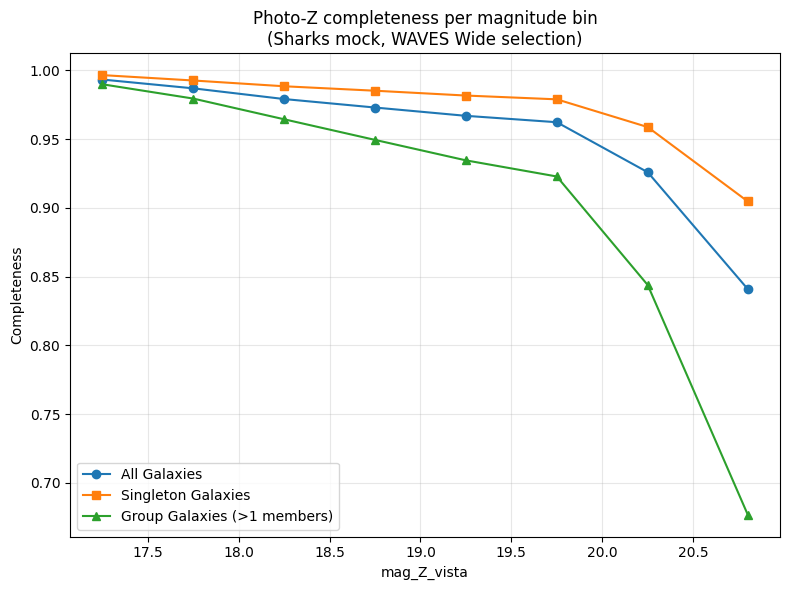

In [39]:
# --- 1. Magnitude bins ---
wide_sharks['photoz_completeness'] = sharks_completeness_para

bins = np.array([17, 17.5,18, 18.5, 19, 19.5, 20, 20.5, 21.1])
bin_centers = 0.5 * (bins[:-1] + bins[1:])
wide_sharks['mag_bin'] = pd.cut(wide_sharks['mag_Z_VISTA'], bins=bins, include_lowest=True)

# --- 2. Group sizes ---
group_sizes = wide_sharks[wide_sharks['id_fof'] != -1].groupby('id_fof').size()
wide_sharks['group_size'] = wide_sharks['id_fof'].map(group_sizes)
wide_sharks.loc[wide_sharks['id_fof'] == -1, 'group_size'] = 1  # field = size 1

# Categories
wide_sharks['category'] = 'multi'
wide_sharks.loc[wide_sharks['group_size'] == 1, 'category'] = 'single'

# --- 3. Define estimator: sum(completeness) / N ---
def completeness_estimator(x):
    return x.sum() / x.count()

# Compute per bin
mean_all = wide_sharks.groupby('mag_bin')['photoz_completeness'].apply(completeness_estimator)

mean_single = wide_sharks[wide_sharks['category'] == 'single'] \
    .groupby('mag_bin')['photoz_completeness'].apply(completeness_estimator)

mean_multi = wide_sharks[wide_sharks['category'] == 'multi'] \
    .groupby('mag_bin')['photoz_completeness'].apply(completeness_estimator)

# --- 4. Plot ---
plt.figure(figsize=(8,6))

plt.plot(bin_centers, mean_all.values, marker='o', label='All Galaxies')
plt.plot(bin_centers, mean_single.values, marker='s', label='Singleton Galaxies')
plt.plot(bin_centers, mean_multi.values, marker='^', label='Group Galaxies (>1 members)')

plt.title('Photo-Z completeness per magnitude bin\n(Sharks mock, WAVES Wide selection)')
plt.xlabel('mag_Z_vista')
plt.ylabel('Completeness')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("completeness_vs_mag_shark.png", dpi=150)
plt.show()

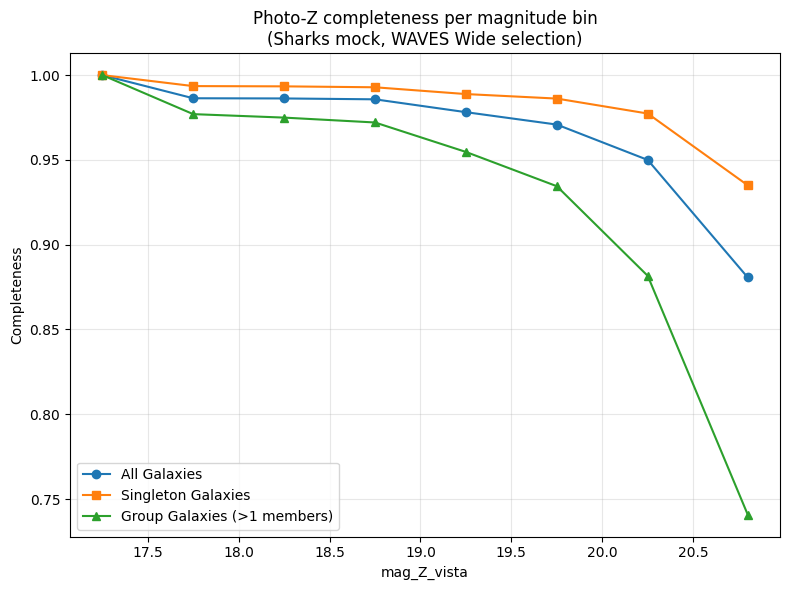

In [40]:
# --- 1. Magnitude bins ---
wide_sharks['photoz_completeness'] = sharks_completeness_emp

bins = np.array([17, 17.5,18, 18.5, 19, 19.5, 20, 20.5, 21.1])
bin_centers = 0.5 * (bins[:-1] + bins[1:])
wide_sharks['mag_bin'] = pd.cut(wide_sharks['mag_Z_VISTA'], bins=bins, include_lowest=True)

# --- 2. Group sizes ---
group_sizes = wide_sharks[wide_sharks['id_fof'] != -1].groupby('id_fof').size()
wide_sharks['group_size'] = wide_sharks['id_fof'].map(group_sizes)
wide_sharks.loc[wide_sharks['id_fof'] == -1, 'group_size'] = 1  # field = size 1

# Categories
wide_sharks['category'] = 'multi'
wide_sharks.loc[wide_sharks['group_size'] == 1, 'category'] = 'single'

# --- 3. Define estimator: sum(completeness) / N ---
def completeness_estimator(x):
    return x.sum() / x.count()

# Compute per bin
mean_all = wide_sharks.groupby('mag_bin')['photoz_completeness'].apply(completeness_estimator)

mean_single = wide_sharks[wide_sharks['category'] == 'single'] \
    .groupby('mag_bin')['photoz_completeness'].apply(completeness_estimator)

mean_multi = wide_sharks[wide_sharks['category'] == 'multi'] \
    .groupby('mag_bin')['photoz_completeness'].apply(completeness_estimator)

# --- 4. Plot ---
plt.figure(figsize=(8,6))

plt.plot(bin_centers, mean_all.values, marker='o', label='All Galaxies')
plt.plot(bin_centers, mean_single.values, marker='s', label='Singleton Galaxies')
plt.plot(bin_centers, mean_multi.values, marker='^', label='Group Galaxies (>1 members)')

plt.title('Photo-Z completeness per magnitude bin\n(Sharks mock, WAVES Wide selection)')
plt.xlabel('mag_Z_vista')
plt.ylabel('Completeness')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("completeness_vs_mag_shark.png", dpi=150)
plt.show()

In [41]:
# --- Group sizes ---
group_sizes = wide_sharks[wide_sharks['id_fof'] != -1].groupby('id_fof').size()
wide_sharks['group_size'] = wide_sharks['id_fof'].map(group_sizes)
wide_sharks.loc[wide_sharks['id_fof'] == -1, 'group_size'] = 1  # field = size 1

# Define masks
mask_single = wide_sharks['group_size'] == 1        # field + 1-member groups
mask_multi  = wide_sharks['group_size'] > 1         # real groups

# --- Completeness estimator: sum / N ---
def completeness(x):
    return x.sum() / x.count()

# --- Compute totals ---
comp_all    = completeness(wide_sharks['photoz_completeness'])
comp_single = completeness(wide_sharks.loc[mask_single, 'photoz_completeness'])
comp_multi  = completeness(wide_sharks.loc[mask_multi,  'photoz_completeness'])

print("All sample:", comp_all)
print("No groups (field + 1-member):", comp_single)
print("Groups (>1 members):", comp_multi)

All sample: 0.9594325569879455
No groups (field + 1-member): 0.9772542864430727
Groups (>1 members): 0.9267050172618698


In [43]:
# --- Group sizes ---
max_mag_lim = 20.8
wide_sharks_lim = wide_sharks[wide_sharks['mag_Z_VISTA'] < max_mag_lim].copy()

group_sizes = wide_sharks_lim[wide_sharks_lim['id_fof'] != -1].groupby('id_fof').size()
wide_sharks_lim['group_size'] = wide_sharks_lim['id_fof'].map(group_sizes)
wide_sharks_lim.loc[wide_sharks_lim['id_fof'] == -1, 'group_size'] = 1  # field = size 1

# Define masks
mask_single = wide_sharks_lim['group_size'] == 1        # field + 1-member groups
mask_multi  = wide_sharks_lim['group_size'] > 1         # real groups

# --- Completeness estimator: sum / N ---
def completeness(x):
    return x.sum() / x.count()

# --- Compute totals ---
comp_all    = completeness(wide_sharks_lim['photoz_completeness'])
comp_single = completeness(wide_sharks_lim.loc[mask_single, 'photoz_completeness'])
comp_multi  = completeness(wide_sharks_lim.loc[mask_multi,  'photoz_completeness'])

print("All sample:", comp_all)
print("No groups (field + 1-member):", comp_single)
print("Groups (>1 members):", comp_multi)

All sample: 0.9652049938807362
No groups (field + 1-member): 0.9787545019267537
Groups (>1 members): 0.9403659268442183
